In [1]:
import shap
import lightgbm as lgb
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import numpy as np

In [2]:
labelled_df = pd.read_parquet('train_labelled.parquet', engine='pyarrow')
labelled_df.head()

,clean_text,party,sentiment,sentiment_score
0,maga maha trumpvance2024 trump2024 magamovemen...,republican,positive,0.8479
1,favorite post kamala harris pretending like de...,democrat,positive,0.8545
2,ron desantis signed sb304 price gouging back a...,democrat,positive,0.8979
3,200 people dead hurricane 99 republican voted ...,republican,negative,-0.8662
4,wtaf coward afraid 60 minute 're incapable tel...,republican,negative,-0.9712


In [3]:
print(labelled_df.shape[0])

864378


## Party Classifier

In [4]:
party_model = joblib.load("models/LightGBM_party_classifier.joblib")

tfidf = party_model.named_steps['tfidf']
lgb_model = party_model.named_steps['clf']

sample_idx = np.random.choice(labelled_df.shape[0], 10000, replace=False)
sample_texts = labelled_df['clean_text'].iloc[sample_idx]

X_sample = tfidf.transform(sample_texts)

print(X_sample.shape)

(10000, 20000)


/home/tsaddi01/.local/lib/python3.10/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


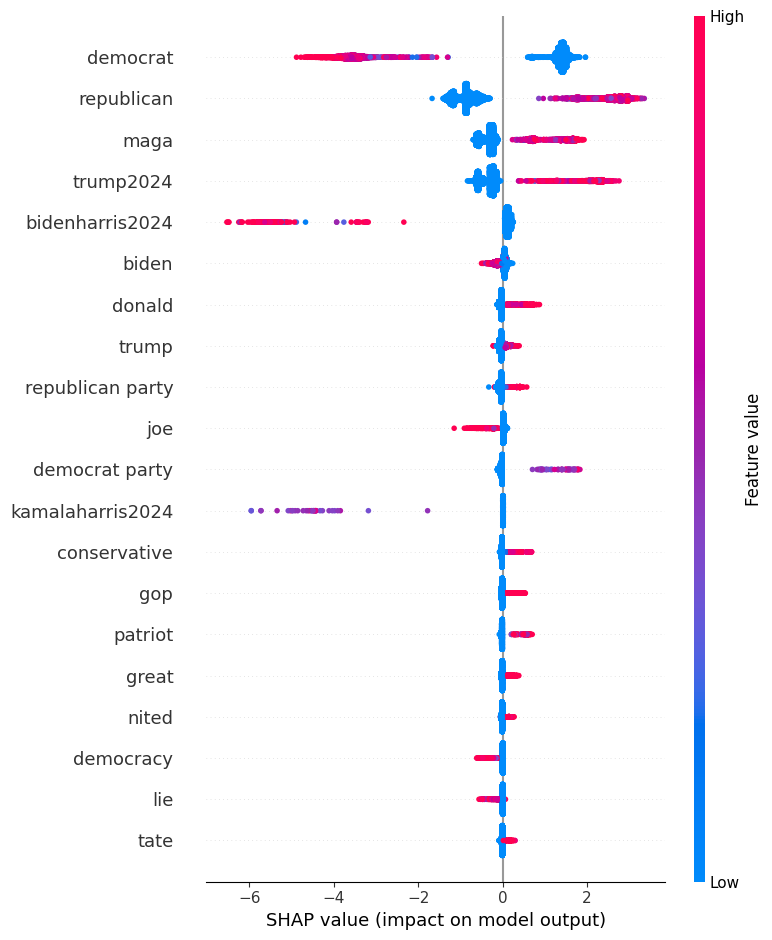

In [5]:
X_sample_dense = X_sample.toarray()

explainer = shap.TreeExplainer(lgb_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample_dense)

# Plot
shap.summary_plot(
    shap_values,
    X_sample_dense,
    feature_names=tfidf.get_feature_names_out()
)


## Democrat Sentiment Classifier

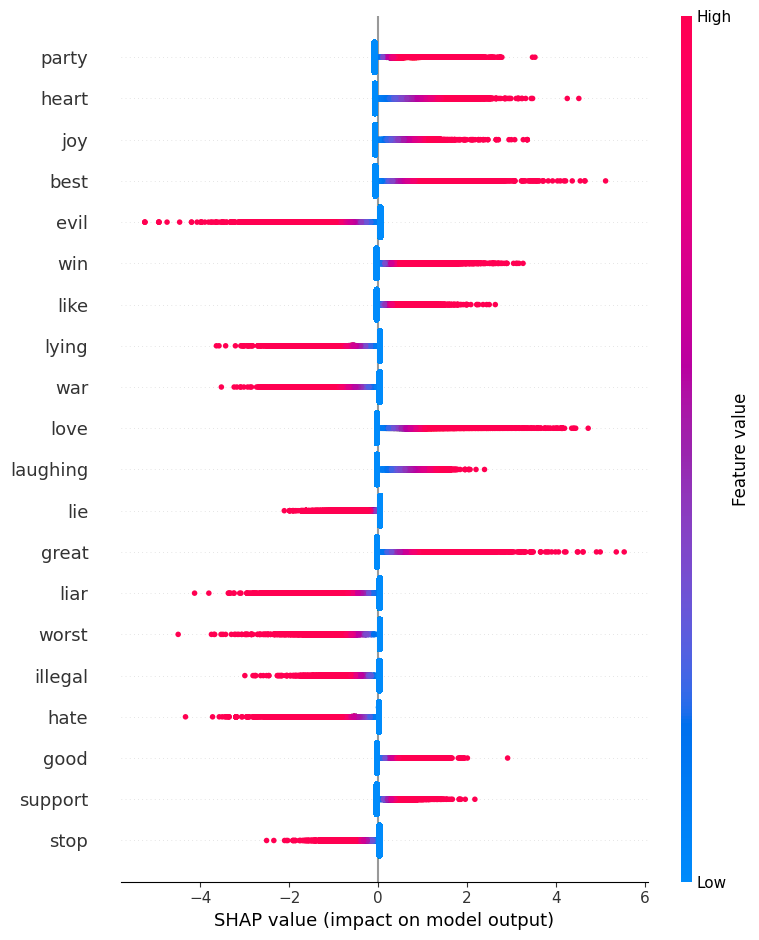

In [6]:
model = joblib.load("models/LinearSVC_democrat_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

democrat_df = labelled_df[labelled_df['party'] == 'democrat'].copy()

democrat_tfidf = tfidf.transform(democrat_df['clean_text'])

democrat_tfidf_dense = democrat_tfidf.toarray()

explainer = shap.LinearExplainer(clf, democrat_tfidf_dense)
shap_values = explainer.shap_values(democrat_tfidf_dense)

shap.summary_plot(
    shap_values, 
    democrat_tfidf_dense, 
    feature_names=tfidf.get_feature_names_out(),
    title="SHAP Summary: Democrat Sentiment Classification"
)

## Republican Sentiment Classifier

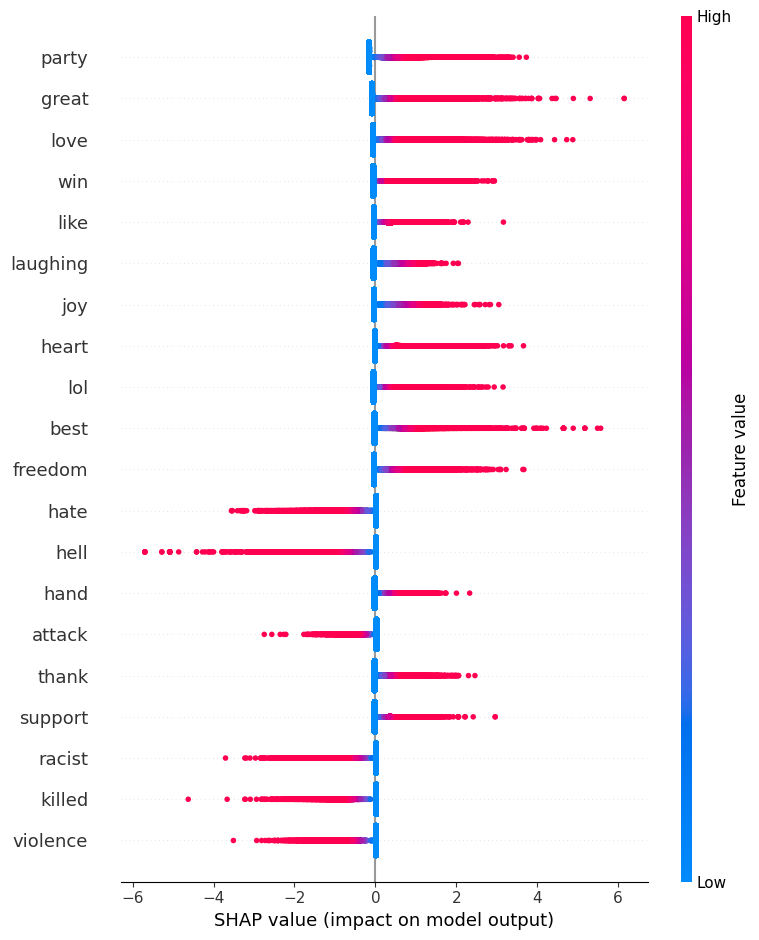

In [7]:

model = joblib.load("models/LinearSVC_republican_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

republican_df = labelled_df[labelled_df['party'] == 'republican'].copy()

republican_tfidf = tfidf.transform(republican_df['clean_text'])
republican_tfidf_dense = republican_tfidf.toarray()

explainer = shap.LinearExplainer(clf, republican_tfidf_dense)
shap_values = explainer.shap_values(republican_tfidf_dense)

shap.summary_plot(
    shap_values, 
    republican_tfidf_dense,
    feature_names=tfidf.get_feature_names_out(),
    title="SHAP Summary: Democrat Sentiment Classification"
)